In [2]:
!pip install monai
!pip install monai[all] nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.0 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 MB 19.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 MB 24.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 57.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 MB 28.4 MB/s eta 0:00:00:00:010

In [3]:
import torch
import torch.nn as nn
import monai
from monai.networks.nets import SwinUNETR
from torch.optim import Adam
import os
import torch
import monai
from monai.data import DataLoader, Dataset, CacheDataset
from monai.transforms import (
    Compose, 
    LoadImaged,
    EnsureTyped, 
    EnsureChannelFirstd, 
    RandCropByPosNegLabeld,
    Spacingd,
    CropForegroundd,
    Orientationd,
    SaveImaged,
    Spacingd,
    Invertd,
)
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json

/opt/conda/lib/python3.10/site-packages/cupy/_environment.py:540: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


In [4]:
train_file = [
   
    {
        "mac_image": "/kaggle/input/originalsuv-ga-psma/train/train/MAC/%d.nii" % idx,
        "nac_image": "/kaggle/input/originalsuv-ga-psma/train/train/NAC/%d.nii" % idx,
    }
    for idx in range(2, 52)
]


train_files, val_files = train_test_split(train_file, test_size=0.15, random_state=0)


train_transforms  = Compose([
    LoadImaged(keys=["nac_image", "mac_image"]),
    EnsureChannelFirstd(keys=["nac_image", "mac_image"]),
    CropForegroundd(keys=["nac_image", "mac_image"], source_key="nac_image"),
    Orientationd(keys=["nac_image", "mac_image"], axcodes="RAS"),
    Spacingd(keys=["nac_image", "mac_image"], pixdim=(3.5, 3.5, 3.5), mode="bilinear"),
    RandCropByPosNegLabeld(
            keys=["nac_image", "mac_image"],
            label_key="mac_image",
            spatial_size=(128, 128, 128),
            num_samples=1,
        ),
    EnsureTyped(keys=["nac_image", "mac_image"]),
])

val_transforms  = Compose([
    LoadImaged(keys=["nac_image", "mac_image"]),
    EnsureChannelFirstd(keys=["nac_image", "mac_image"]), 
    Spacingd(keys=["nac_image", "mac_image"], pixdim=(3.5, 3.5, 3.5), mode="bilinear"),
    CropForegroundd(keys=["nac_image", "mac_image"], source_key="nac_image"),
    Orientationd(keys=["nac_image", "mac_image"], axcodes="RAS"),
    EnsureTyped(keys=["nac_image", "mac_image"]),
])

monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.


In [5]:
volume_ds_train = monai.data.CacheDataset(data=train_files, transform=train_transforms)
train_loader = DataLoader(volume_ds_train, batch_size=1)
check_data_train = monai.utils.misc.first(train_loader)
print("first volume's shape: ", check_data_train["nac_image"].shape, check_data_train["mac_image"].shape)

volume_ds_val = monai.data.CacheDataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(volume_ds_val, batch_size=1)
check_data_val = monai.utils.misc.first(val_loader)
print("first volume's shape: ", check_data_val["nac_image"].shape, check_data_val["mac_image"].shape)

Loading dataset: 100%|██████████| 42/42 [03:49<00:00,  5.47s/it]


first volume's shape:  torch.Size([1, 1, 128, 128, 128]) torch.Size([1, 1, 128, 128, 128])


Loading dataset: 100%|██████████| 8/8 [00:43<00:00,  5.44s/it]

first volume's shape:  torch.Size([1, 1, 200, 200, 327]) torch.Size([1, 1, 200, 200, 327])


In [6]:
class SwinUNETR_Relu(nn.Module):
    def __init__(self):
        super(SwinUNETR_Relu,self).__init__()
        self.unet=SwinUNETR(
            img_size=(128,128,128),
            in_channels=1,
            out_channels=1,
            depths=(2, 2, 2, 2),
            num_heads=(3, 6, 12, 24),
            feature_size=24,
            use_checkpoint=True,
            spatial_dims=3
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.unet(x)
        x = self.relu(x)  
        return x

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=SwinUNETR_Relu().to(device)

monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().


In [ ]:
from torch.nn import L1Loss
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from monai.inferers import sliding_window_inference

# Parameters
num_epochs = 500
#batch_size = 8



loss_function = L1Loss()
optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=40, gamma=0.98)


best_loss = float("inf")
best_loss_epoch = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    
    model.train()
    epoch_loss = 0
    step=0
    for batch in train_loader:
        step+=1
        
        images = batch["nac_image"].to(device)
        labels = batch["mac_image"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    
    epoch_loss /= step
    train_losses.append(epoch_loss)
    print(f"Training Loss: {epoch_loss:.4f}")

    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        step=0
        for val_batch in val_loader:
            step+=1
            val_images = val_batch["nac_image"].to(device)
            val_labels = val_batch["mac_image"].to(device)
            roi_size = (128, 128, 128)
            sw_batch_size = 1
            val_outputs = sliding_window_inference(
                                            val_images,
                                            roi_size, 
                                            sw_batch_size,
                                            model,          # model as positional argument
                                            overlap=0.6      # keyword argument
                                        )
            val_loss += loss_function(val_outputs, val_labels).item()

    val_loss /= step
    val_losses.append(val_loss)
    print(f"Validation Loss: {val_loss:.4f}")

    # Save the best model
    if val_loss < best_loss:
        best_loss = val_loss
        best_loss_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_loss': best_loss,
            'best_loss_epoch': best_loss_epoch,
        }, "best_swinUNetr_model.pth")
        print("*******Saved new best model*******")
        loss_save_path = f"best_losses.json"
        with open(loss_save_path, "w") as f:
            json.dump({"train_losses": train_losses, "val_losses": val_losses}, f)

    scheduler.step()

print(f"Training completed. Best validation loss: {best_loss:.4f} at epoch {best_loss_epoch}")

Epoch 1/500


`torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.


Training Loss: 0.1902
Validation Loss: 0.0753
*******Saved new best model*******
Epoch 2/500
Training Loss: 0.1680
Validation Loss: 0.0678
*******Saved new best model*******
Epoch 3/500
Training Loss: 0.1294
Validation Loss: 0.0659
*******Saved new best model*******
Epoch 4/500
Training Loss: 0.1340
Validation Loss: 0.0622
*******Saved new best model*******
Epoch 5/500
Training Loss: 0.1731
Validation Loss: 0.0572
*******Saved new best model*******
Epoch 6/500
Training Loss: 0.1335
Validation Loss: 0.0572
Epoch 7/500
Training Loss: 0.1294
Validation Loss: 0.0624
Epoch 8/500
Training Loss: 0.1320
Validation Loss: 0.0545
*******Saved new best model*******
Epoch 9/500
Training Loss: 0.1254
Validation Loss: 0.0512
*******Saved new best model*******
Epoch 10/500
Training Loss: 0.1278
Validation Loss: 0.0487
*******Saved new best model*******
Epoch 11/500
Training Loss: 0.1363
Validation Loss: 0.0476
*******Saved new best model*******
Epoch 12/500
Training Loss: 0.1045
Validation Loss: 0.047

In [ ]:
import torch
import os
from monai.inferers import sliding_window_inference

num_epochs = 500
#batch_size = 8


loss_function = torch.nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.98)

best_loss = float("inf")
best_loss_epoch = 0

#train_losses = []
#val_losses = []
with open("/kaggle/working/best_losses.json", "r") as f:
    losses = json.load(f)

train_losses = losses["train_losses"]
val_losses = losses["val_losses"]
# Check if there is an existing checkpoint
checkpoint_path = "/kaggle/working/best_swinUNetr_model.pth"
#start_epoch = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_loss = checkpoint['best_loss']
    best_loss_epoch = checkpoint['best_loss_epoch']
    print(f"Loaded checkpoint from epoch {start_epoch}, with best loss {best_loss:.4f} at epoch {best_loss_epoch}")

# Continue training from the last saved epoch
for epoch in range(start_epoch, num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    model.train()
    epoch_loss = 0
    step=0
    for batch in train_loader:
        step+=1
        
        images = batch["nac_image"].to(device)
        labels = batch["mac_image"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    
    epoch_loss /= step
    train_losses.append(epoch_loss)
    print(f"Training Loss: {epoch_loss:.4f}")

    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        step=0
        for val_batch in val_loader:
            step+=1
            val_images = val_batch["nac_image"].to(device)
            val_labels = val_batch["mac_image"].to(device)
            roi_size = (128, 128, 128)
            sw_batch_size = 1
            val_outputs = sliding_window_inference(
                                            val_images,
                                            roi_size, 
                                            sw_batch_size,
                                            model,          # model as positional argument
                                            overlap=0.6      # keyword argument
                                        )
            val_loss += loss_function(val_outputs, val_labels).item()

    val_loss /= step
    val_losses.append(val_loss)
    print(f"Validation Loss: {val_loss:.4f}")

    # Save the best model
    if val_loss < best_loss:
        best_loss = val_loss
        best_loss_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_loss': best_loss,
            'best_loss_epoch': best_loss_epoch,
        }, "best_swinUNetr_model.pth")
        print("Saved new best model")
        loss_save_path = f"best_losses.json"
        with open(loss_save_path, "w") as f:
            json.dump({"train_losses": train_losses, "val_losses": val_losses}, f)

    scheduler.step()

print(f"Training completed. Best validation loss: {best_loss:.4f} at epoch {best_loss_epoch}")

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loaded checkpoint from epoch 67, with best loss 0.0248 at epoch 67
Epoch 68/500
Training Loss: 0.0674
Validation Loss: 0.0262
Epoch 69/500
Training Loss: 0.0581
Validation Loss: 0.0267
Epoch 70/500
Training Loss: 0.0570
Validation Loss: 0.0247
Saved new best model
Epoch 71/500
Training Loss: 0.0744
Validation Loss: 0.0358
Epoch 72/500
Training Loss: 0.0664
Validation Loss: 0.0243
Saved new best model
Epoch 73/500
Training Loss: 0.0644
Validation Loss: 0.0261
Epoch 74/500
Training Loss: 0.0567
Validation Loss: 0.0242
Saved new best model
Epoch 75/500
Training Loss: 0.0601
Validation Loss: 0.0225
Saved new best model
Epoch 76/500
Training Loss: 0.0591
Validation Loss: 0.0241
Epoch 77/500
Training Loss: 0.0774
Validation Loss: 0.0284
Epoch 78/500
Training Loss: 0.0630
Validation Loss: 0.0224
Saved new best model
Epoch 79/500
Training Loss: 0.0626
Validation Loss: 0.0233
Epoch 80/500
Training Loss: 0.0558
Validation Loss: 0.0244
Epoch 81/500
Training Loss: 0.0521
Validation Loss: 0.0243
Ep

In [ ]:
import torch
import os
from monai.inferers import sliding_window_inference

num_epochs = 500
#batch_size = 8


loss_function = torch.nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.98)

best_loss = float("inf")
best_loss_epoch = 0

#train_losses = []
#val_losses = []
with open("/kaggle/working/best_losses.json", "r") as f:
    losses = json.load(f)

train_losses = losses["train_losses"]
val_losses = losses["val_losses"]
# Check if there is an existing checkpoint
checkpoint_path = "/kaggle/working/best_swinUNetr_model.pth"
#start_epoch = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_loss = checkpoint['best_loss']
    best_loss_epoch = checkpoint['best_loss_epoch']
    print(f"Loaded checkpoint from epoch {start_epoch}, with best loss {best_loss:.4f} at epoch {best_loss_epoch}")

# Continue training from the last saved epoch
for epoch in range(start_epoch, num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    model.train()
    epoch_loss = 0
    step=0
    for batch in train_loader:
        step+=1
        
        images = batch["nac_image"].to(device)
        labels = batch["mac_image"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    
    epoch_loss /= step
    train_losses.append(epoch_loss)
    print(f"Training Loss: {epoch_loss:.4f}")

    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        step=0
        for val_batch in val_loader:
            step+=1
            val_images = val_batch["nac_image"].to(device)
            val_labels = val_batch["mac_image"].to(device)
            roi_size = (128, 128, 128)
            sw_batch_size = 1
            val_outputs = sliding_window_inference(
                                            val_images,
                                            roi_size, 
                                            sw_batch_size,
                                            model,          # model as positional argument
                                            overlap=0.6      # keyword argument
                                        )
            val_loss += loss_function(val_outputs, val_labels).item()

    val_loss /= step
    val_losses.append(val_loss)
    print(f"Validation Loss: {val_loss:.4f}")

    # Save the best model
    if val_loss < best_loss:
        best_loss = val_loss
        best_loss_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_loss': best_loss,
            'best_loss_epoch': best_loss_epoch,
        }, "*****best_swinUNetr_model.pth*******")
        print("Saved new best model")
        loss_save_path = f"best_losses.json"
        with open(loss_save_path, "w") as f:
            json.dump({"train_losses": train_losses, "val_losses": val_losses}, f)

    scheduler.step()

print(f"Training completed. Best validation loss: {best_loss:.4f} at epoch {best_loss_epoch}")

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loaded checkpoint from epoch 90, with best loss 0.0221 at epoch 90
Epoch 91/500


`torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.


Training Loss: 0.0615
Validation Loss: 0.0362
Epoch 92/500
Training Loss: 0.0627
Validation Loss: 0.0234
Epoch 93/500
Training Loss: 0.0532
Validation Loss: 0.0270
Epoch 94/500
Training Loss: 0.0501
Validation Loss: 0.0229
Epoch 95/500
Training Loss: 0.0650
Validation Loss: 0.0235
Epoch 96/500
Training Loss: 0.0604
Validation Loss: 0.0240
Epoch 97/500
Training Loss: 0.0580
Validation Loss: 0.0278
Epoch 98/500
Training Loss: 0.0708
Validation Loss: 0.0267
Epoch 99/500
Training Loss: 0.0546
Validation Loss: 0.0231
Epoch 100/500
Training Loss: 0.0530
Validation Loss: 0.0258
Epoch 101/500
Training Loss: 0.0558
Validation Loss: 0.0218
Saved new best model
Epoch 102/500
Training Loss: 0.0517
Validation Loss: 0.0221
Epoch 103/500
Training Loss: 0.0593
Validation Loss: 0.0242
Epoch 104/500
Training Loss: 0.0593
Validation Loss: 0.0302
Epoch 105/500
Training Loss: 0.0592
Validation Loss: 0.0253
Epoch 106/500
Training Loss: 0.0577
Validation Loss: 0.0222
Epoch 107/500
Training Loss: 0.0506
Valid

In [8]:
import torch
import os
from monai.inferers import sliding_window_inference

num_epochs = 500
#batch_size = 8


loss_function = torch.nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.98)

best_loss = float("inf")
best_loss_epoch = 0

#train_losses = []
#val_losses = []
with open("/kaggle/working/best_losses.json", "r") as f:
    losses = json.load(f)

train_losses = losses["train_losses"]
val_losses = losses["val_losses"]
# Check if there is an existing checkpoint
checkpoint_path = "/kaggle/working/*****best_swinUNetr_model.pth*******"
#start_epoch = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_loss = checkpoint['best_loss']
    best_loss_epoch = checkpoint['best_loss_epoch']
    print(f"Loaded checkpoint from epoch {start_epoch}, with best loss {best_loss:.4f} at epoch {best_loss_epoch}")

# Continue training from the last saved epoch
for epoch in range(start_epoch, num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    model.train()
    epoch_loss = 0
    step=0
    for batch in train_loader:
        step+=1
        
        images = batch["nac_image"].to(device)
        labels = batch["mac_image"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    
    epoch_loss /= step
    train_losses.append(epoch_loss)
    print(f"Training Loss: {epoch_loss:.4f}")

    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        step=0
        for val_batch in val_loader:
            step+=1
            val_images = val_batch["nac_image"].to(device)
            val_labels = val_batch["mac_image"].to(device)
            roi_size = (128, 128, 128)
            sw_batch_size = 1
            val_outputs = sliding_window_inference(
                                            val_images,
                                            roi_size, 
                                            sw_batch_size,
                                            model,          # model as positional argument
                                            overlap=0.6      # keyword argument
                                        )
            val_loss += loss_function(val_outputs, val_labels).item()

    val_loss /= step
    val_losses.append(val_loss)
    print(f"Validation Loss: {val_loss:.4f}")

    # Save the best model
    if val_loss < best_loss:
        best_loss = val_loss
        best_loss_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_loss': best_loss,
            'best_loss_epoch': best_loss_epoch,
        }, "best_swinUNetr_model.pth")
        print("*********Saved new best model**********")
        loss_save_path = f"best_losses.json"
        with open(loss_save_path, "w") as f:
            json.dump({"train_losses": train_losses, "val_losses": val_losses}, f)

    scheduler.step()

print(f"Training completed. Best validation loss: {best_loss:.4f} at epoch {best_loss_epoch}")

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loaded checkpoint from epoch 308, with best loss 0.0180 at epoch 308
Epoch 309/500


`torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.


Training Loss: 0.0426
Validation Loss: 0.0199
Epoch 310/500
Training Loss: 0.0416
Validation Loss: 0.0206
Epoch 311/500
Training Loss: 0.0398
Validation Loss: 0.0196
Epoch 312/500
Training Loss: 0.0374
Validation Loss: 0.0182
Epoch 313/500
Training Loss: 0.0411
Validation Loss: 0.0239
Epoch 314/500
Training Loss: 0.0424
Validation Loss: 0.0202
Epoch 315/500
Training Loss: 0.0451
Validation Loss: 0.0190
Epoch 316/500
Training Loss: 0.0401
Validation Loss: 0.0190
Epoch 317/500
Training Loss: 0.0454
Validation Loss: 0.0187
Epoch 318/500
Training Loss: 0.0363
Validation Loss: 0.0193
Epoch 319/500
Training Loss: 0.0413
Validation Loss: 0.0186
Epoch 320/500
Training Loss: 0.0397
Validation Loss: 0.0184
Epoch 321/500
Training Loss: 0.0408
Validation Loss: 0.0185
Epoch 322/500
Training Loss: 0.0395
Validation Loss: 0.0192
Epoch 323/500
Training Loss: 0.0412
Validation Loss: 0.0180
*********Saved new best model**********
Epoch 324/500
Training Loss: 0.0398
Validation Loss: 0.0181
Epoch 325/500


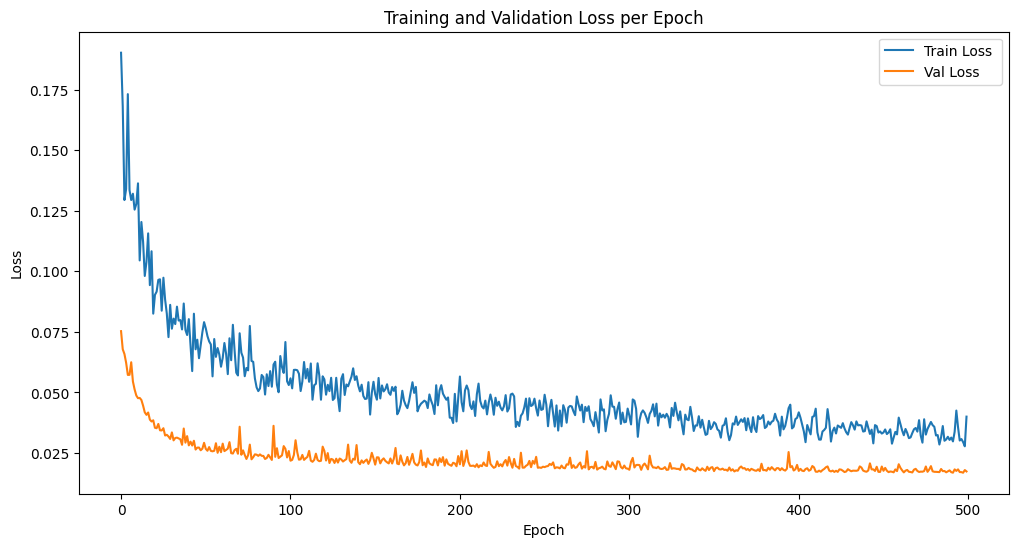

In [9]:
import json
import matplotlib.pyplot as plt

# Load losses from JSON file
#with open("best_losses.json", "r") as f:
    #losses = json.load(f)

#train_losses = losses["train_losses"]
#val_losses = losses["val_losses"]
plt.figure(figsize=(12, 6))



plt.plot(train_losses, label='Train Loss ')
plt.plot(val_losses, label='Val Loss ')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.show()

In [10]:
import os
import torch
import monai
from monai.data import DataLoader, Dataset, CacheDataset
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstD, ScaleIntensityRanged, Orientationd,
    Spacingd, EnsureTyped, EnsureType
)

test_files =  [
    {

        "nac_image": "/kaggle/input/originalsuv-ga-psma/test1/test1/NAC/%d.nii" % idx,
        
    }
    for idx in range(1, 19)
]

test_transforms = Compose([
    LoadImaged(keys=["nac_image"]),
    EnsureChannelFirstd(keys=["nac_image"]), 
    Spacingd(keys=["nac_image"], pixdim=(3.5, 3.5, 3.5), mode="bilinear"),
    CropForegroundd(keys=["nac_image"], source_key="nac_image"),
    Orientationd(keys=["nac_image"], axcodes="RAS"),
    EnsureTyped(keys=["nac_image"]),
])
test_ds = Dataset(data=test_files, transform=test_transforms)
test_loader = DataLoader(test_ds, batch_size=1, num_workers=2)

post_transforms = Compose(
    [
        Invertd(
            keys="pred",
            transform=test_transforms,
            orig_keys="nac_image",
            meta_keys="pred_meta_dict",
            orig_meta_keys="image_meta_dict",
            meta_key_postfix="meta_dict",
            nearest_interp=False,
            to_tensor=True,
            device="cpu",
        ),
        SaveImaged(keys="pred", meta_keys="pred_meta_dict", output_dir="/kaggle/working", output_postfix="pred", resample=False)
    ]
)

In [11]:
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch
import nibabel as nib

class SwinUNETR_Relu(nn.Module):
    def __init__(self):
        super(SwinUNETR_Relu,self).__init__()
        self.unet=SwinUNETR(
            img_size=(128,128,128),
            in_channels=1,
            out_channels=1,
            depths=(2, 2, 2, 2),
            num_heads=(3, 6, 12, 24),
            feature_size=24,
            use_checkpoint=True,
            spatial_dims=3
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.unet(x)
        x = self.relu(x)  
        return x
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=SwinUNETR_Relu().to(device)    
    
checkpoint = torch.load("/kaggle/working/best_swinUNetr_model.pth")

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

output_directory = "/kaggle/working/"
with torch.no_grad():
    for test_data in test_loader:
        test_image = test_data["nac_image"].to(device)
        roi_size = (128, 128, 128)
        sw_batch_size = 1
        test_data ["pred"] = sliding_window_inference(
                                        test_image,
                                        roi_size, 
                                        sw_batch_size,
                                        model,          
                                        overlap=0.6     
                                    )

        pred_data = [post_transforms(i) for i in decollate_batch(test_data)]

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


2024-10-23 14:17:08,878 INFO image_writer.py:197 - writing: /kaggle/working/1/1_pred.nii.gz
2024-10-23 14:17:21,844 INFO image_writer.py:197 - writing: /kaggle/working/2/2_pred.nii.gz
2024-10-23 14:17:34,771 INFO image_writer.py:197 - writing: /kaggle/working/3/3_pred.nii.gz
2024-10-23 14:17:47,704 INFO image_writer.py:197 - writing: /kaggle/working/4/4_pred.nii.gz
2024-10-23 14:18:00,660 INFO image_writer.py:197 - writing: /kaggle/working/5/5_pred.nii.gz
2024-10-23 14:18:13,593 INFO image_writer.py:197 - writing: /kaggle/working/6/6_pred.nii.gz
2024-10-23 14:18:26,600 INFO image_writer.py:197 - writing: /kaggle/working/7/7_pred.nii.gz
2024-10-23 14:18:39,568 INFO image_writer.py:197 - writing: /kaggle/working/8/8_pred.nii.gz
2024-10-23 14:18:52,643 INFO image_writer.py:197 - writing: /kaggle/working/9/9_pred.nii.gz
2024-10-23 14:19:05,628 INFO image_writer.py:197 - writing: /kaggle/working/10/10_pred.nii.gz
2024-10-23 14:19:18,702 INFO image_writer.py:197 - writing: /kaggle/working/11

os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
